In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [93]:
y1 = lambda x: np.sin(x)
y2 = lambda x: np.cos(x)
y3 = lambda x: np.sin(x) + np.cos(x)
y4 = lambda x: np.sin(x)**2 + x * np.cos(x) + np.cos(x)**2

In [94]:
time = np.linspace(0, 10, 1000)

In [95]:
missing_idx = np.random.choice(time.size, size=int(time.size * 0.3), replace=False)
missing_time = time[missing_idx]
observed_time = np.delete(time, missing_idx)

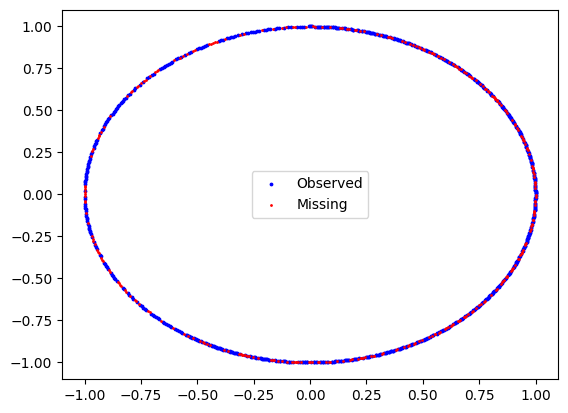

In [96]:
plt.scatter(y1(observed_time), y2(observed_time), s=3, label='Observed', color='blue')
plt.scatter(y1(missing_time), y2(missing_time), s=1, label='Missing', color='red')
plt.legend()

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
Y = np.vstack((y1(missing_time), y2(missing_time), y3(missing_time), y4(missing_time))).T
Y_obs = np.vstack((y1(observed_time), y2(observed_time), y3(observed_time), y4(observed_time))).T
X_filled = imputer.fit_transform(Y)

In [109]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Y = scaler.fit_transform(Y)
Y_obs = scaler.transform(Y_obs)
X_filled = scaler.transform(X_filled)

In [110]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)  # rank < number of features

In [111]:
a = pca.fit_transform(Y_obs)

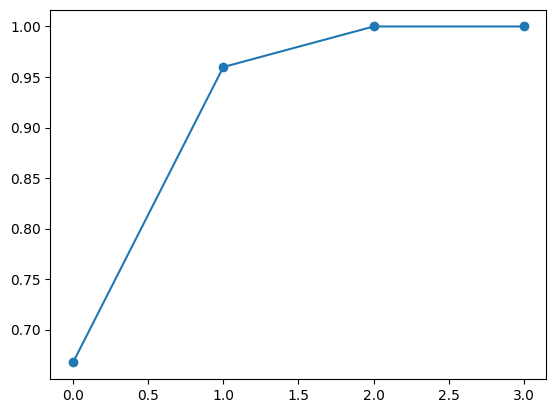

In [112]:
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

In [120]:
pca = PCA(n_components=2)  # rank < number of features

In [121]:
X_transformed = pca.fit_transform(X_filled)
X_reconstructed = pca.inverse_transform(X_transformed)

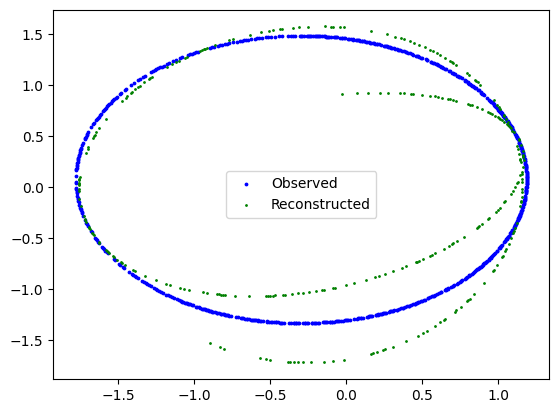

In [126]:
plt.scatter(Y_obs[:, 0], Y_obs[:, 1], s=3, label='Observed', color='blue')
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], s=1, label='Reconstructed', color='green')
plt.legend()